# Adversarial Robustness Heatmaps

This notebook generates summary heatmaps from the result tables (`results/tableIII.csv` through `results/tableVIII.csv`). The goal is to provide a single visual artifact that complements the dense per-attack tables in the paper and makes the two failure modes (false alarms and missed attacks) comparable at a glance.

**Rows:** 5 IDS models (DT, RF, ET, XGBoost, DNN).

**Columns:** 6 attack scenarios × 3 adversarial methods (FGSM, BIM, PGD) = 18 columns per panel.

**Cell value:** ASR averaged over the two perturbation budgets (ε = 1, 5). Color is on a white→red scale: darker red means the attacker succeeds more often (less robust IDS).

Two panels are produced:
- **(a) ASR_[FP]** – adversarially induced false alarms (benign samples perturbed into malicious predictions).
- **(b) ASR_[FN]** – missed attacks (malicious samples perturbed into benign predictions).

CSA does not produce valid FN adversarial samples (the protocol-compliance filter discards them; see Section IV.F of the paper), so the CSA column in panel (b) is rendered with a hatched pattern labeled `N/A`.

Saved: Paper/Figures/figure_heatmap_combined.pdf
Saved: Paper/Figures/figure_heatmap_combined.png


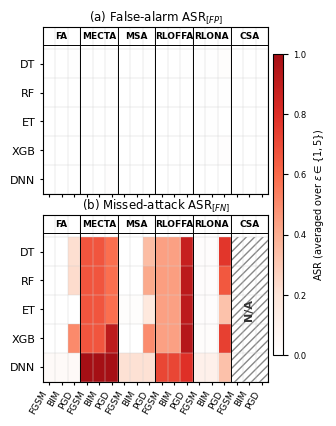

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle

RESULTS_DIR = "results"
OUT_DIR = "Paper/Figures"
os.makedirs(OUT_DIR, exist_ok=True)

# Canonical ordering used throughout the paper
MODEL_ORDER = ["DT", "RF", "ET", "XGBoost", "DNN"]
ATTACK_ORDER = ["FGSM", "BIM", "PGD"]
SCENARIOS = [
    ("FA",    "tableIII.csv"),
    ("MECTA", "tableIV.csv"),
    ("MSA",   "tableV.csv"),
    ("RLOFFA","tableVI.csv"),
    ("RLONA", "tableVII.csv"),
    ("CSA",   "tableVIII.csv"),
]

def load_scenario(fname):
    """Load a result CSV and normalise column names.

    Tables III–VII share a common schema: Model, Benign FP, Benign FN, MCC,
    Benign F1, Attack, Epsilon, Adv FP, ASR (FP), Adv FN, ASR (FN), Adv F1,
    Adv MCC, ASR. Table VIII (CSA) has no FN columns because no valid
    protocol-compliant CSA FN samples exist; we inject NaN so the heatmap
    can mask that column.
    """
    df = pd.read_csv(os.path.join(RESULTS_DIR, fname))
    if "ASR (FN)" not in df.columns:
        df["ASR (FN)"] = np.nan
    return df[["Model", "Attack", "Epsilon", "ASR (FP)", "ASR (FN)"]]

frames = []
for scen, fname in SCENARIOS:
    sub = load_scenario(fname)
    sub["Scenario"] = scen
    frames.append(sub)
long = pd.concat(frames, ignore_index=True)
long.head()

def build_matrix(column):
    """Return a (models × scenario×attack) matrix averaged over ε.

    Averaging across ε ∈ {1, 5} gives a single summary of attacker success.
    Since the paper evaluates only these two extremes and intermediate values
    would interpolate monotonically (per Reviewer 3's ablation suggestion),
    the mean preserves the ordering of model robustness while compressing
    the figure from 36 to 18 columns per panel.
    """
    pivot = (long.groupby(["Model", "Scenario", "Attack"])[column]
                   .mean()
                   .reset_index())
    pivot["Model"] = pd.Categorical(pivot["Model"], categories=MODEL_ORDER, ordered=True)
    pivot["Scenario"] = pd.Categorical(
        pivot["Scenario"], categories=[s for s, _ in SCENARIOS], ordered=True
    )
    pivot["Attack"] = pd.Categorical(pivot["Attack"], categories=ATTACK_ORDER, ordered=True)
    mat = pivot.pivot_table(index="Model", columns=["Scenario", "Attack"], values=column, observed=False)
    mat = mat.reindex(index=MODEL_ORDER)
    col_order = [(s, a) for s, _ in SCENARIOS for a in ATTACK_ORDER]
    mat = mat.reindex(columns=col_order)
    return mat

asr_fp = build_matrix("ASR (FP)")
asr_fn = build_matrix("ASR (FN)")
asr_fp.round(3)

# ---------------------------------------------------------------
# Combined figure: FP on top, FN on bottom, sharing the x-axis
# so the whole thing reads as a single Figure 3 in the paper.
# Scenario headers appear on BOTH panels; per-attack tick labels
# (FGSM/BIM/PGD) only on the bottom panel; single shared colorbar.
# ---------------------------------------------------------------
CMAP = LinearSegmentedColormap.from_list(
    "white_red", ["#ffffff", "#fee5d9", "#fcae91", "#fb6a4a", "#de2d26", "#a50f15"]
)

# Display labels use XGB instead of XGBoost to keep axis compact.
MODEL_DISPLAY = ["DT", "RF", "ET", "XGB", "DNN"]


def draw_panel(ax, mat, title, show_xticks):
    data = mat.values.astype(float)
    mask = np.isnan(data)
    data_plot = np.where(mask, 0.0, data)
    n_rows, n_cols = data.shape

    im = ax.imshow(data_plot, cmap=CMAP, vmin=0.0, vmax=1.0, aspect="auto",
                   extent=[-0.5, n_cols - 0.5, n_rows - 0.5, -0.5])

    # Reserve space above data rows for scenario labels on BOTH panels
    ax.set_ylim(n_rows - 0.5, -1.25)
    ax.set_xlim(-0.5, n_cols - 0.5)

    ax.set_xticks(np.arange(n_cols))
    ax.set_yticks(np.arange(n_rows))
    if show_xticks:
        xtick_labels = [a for _, a in mat.columns]
        ax.set_xticklabels(xtick_labels, rotation=60, ha="right", fontsize=6.5)
    else:
        ax.set_xticklabels([])
    ax.set_yticklabels(MODEL_DISPLAY, fontsize=8)

    scenario_names = [s for s, _ in SCENARIOS]
    for i, sc in enumerate(scenario_names):
        start = i * 3
        end = start + 2
        center = (start + end) / 2
        # 6.5pt keeps RLOFFA/RLONA from colliding at column width
        ax.text(center, -0.95, sc, ha="center", va="center",
                fontsize=6.5, fontweight="bold")
        ax.plot([start - 0.45, end + 0.45], [-0.65, -0.65],
                color="black", lw=0.7, clip_on=True)

    for i in range(1, len(scenario_names)):
        ax.axvline(i * 3 - 0.5, color="black", lw=0.7, ymin=0, ymax=1, clip_on=True)

    ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)
    ax.grid(which="minor", color="#d0d0d0", linestyle="-", linewidth=0.3)
    ax.tick_params(which="minor", bottom=False, left=False)
    ax.tick_params(axis="both", which="major", length=2)

    # Mask fully-NaN scenario blocks (CSA in FN panel) with a single rotated N/A
    scenario_fully_masked = []
    for si, sc in enumerate(scenario_names):
        cols = slice(si * 3, si * 3 + 3)
        if mask[:, cols].all():
            scenario_fully_masked.append(si)

    for i in range(n_rows):
        for j in range(n_cols):
            if mask[i, j]:
                ax.add_patch(Rectangle(
                    (j - 0.5, i - 0.5), 1, 1,
                    hatch="////", fill=False, edgecolor="#888888", lw=0.0,
                ))

    for si in scenario_fully_masked:
        xc = si * 3 + 1
        yc = (n_rows - 1) / 2
        ax.text(xc, yc, "N/A", ha="center", va="center",
                fontsize=8, color="#333333", fontweight="bold", rotation=90)

    # Center-aligned title; no y-axis "Model" label
    ax.set_title(title, fontsize=8.5, pad=4)
    ax.set_ylabel("")
    return im


fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(3.5, 4.6), sharex=True,
    gridspec_kw={"height_ratios": [1, 1], "hspace": 0.13}
)

im1 = draw_panel(ax_top, asr_fp,
                 "(a) False-alarm ASR$_{[FP]}$",
                 show_xticks=False)
im2 = draw_panel(ax_bot, asr_fn,
                 "(b) Missed-attack ASR$_{[FN]}$",
                 show_xticks=True)

cbar = fig.colorbar(im2, ax=[ax_top, ax_bot], shrink=0.85, pad=0.02, aspect=30)
cbar.set_label("ASR (averaged over $\epsilon \in \{1,5\}$)", fontsize=7)
cbar.ax.tick_params(labelsize=6)

out_pdf = os.path.join(OUT_DIR, "figure_heatmap_combined.pdf")
out_png = os.path.join(OUT_DIR, "figure_heatmap_combined.png")
plt.savefig(out_pdf, bbox_inches="tight", dpi=300, pad_inches=0.08)
plt.savefig(out_png, bbox_inches="tight", dpi=300, pad_inches=0.08)
print("Saved:", out_pdf)
print("Saved:", out_png)
plt.show()

## Interpretation

The upper panel (false-alarm ASR) is dominated by near-white cells: across all models, attack methods, and scenarios, adversarial perturbations rarely succeed in flipping benign frames into the malicious class. This is consistent with the paper's observation that benign traffic classification is stable under the protocol-compliant budget.

The lower panel (missed-attack ASR) tells the opposite story. DNN rows saturate to dark red on MECTA and RLOFFA, confirming the paper's statement that the DNN exhibits catastrophic missed-attack behaviour in specific scenarios despite its strong benign performance. XGBoost shows a softer but still visible red band under PGD. ET maintains comparatively light colour across scenarios, visually reinforcing the paper's conclusion that ET offers the most favourable robustness trade-off.

The two panels make the paper's central argument visible in one figure: false alarms and missed attacks are **not** symmetric failure modes — a model can look safe in panel (a) and still be fully compromised in panel (b).